LAB02 - Tarefa 02

Utilizar a mesma base de dados da Tarefa i, mas trabalhar com um espaço dimensional de característica bem maior. Para trabalhar nesta tarefa baixar o arquivo DadosWH.csv disponibilizado na nossa Comunidade da disciplina no Moodle©. Para isso baixar o arquivo Lab02Tarefa02 disponibilizado na nossa Comunidade da disciplina no Moodle©

In [4]:
# Importa as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import numpy as np

In [5]:
# Carrega minha pasta do GoogleDrive onde está localizada a base de dados
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
dados = pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Aula02 - k-means e k-medoids/DadosWH.csv')
dados

,Name,Continent,year,population,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
0,Afghanistan,Asia,2010,29185507.0,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
1,Afghanistan,Asia,2011,30117413.0,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
2,Afghanistan,Asia,2012,31161376.0,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268
3,Afghanistan,Asia,2013,32269589.0,3.572,7.725,0.484,52.56,0.578,0.061,0.823,0.621,0.273
4,Afghanistan,Asia,2014,33370794.0,3.131,7.718,0.526,52.88,0.509,0.104,0.871,0.532,0.375
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215,Zimbabwe,Africa,2015,13814629.0,3.703,7.992,0.736,53.80,0.667,-0.123,0.810,0.715,0.179
1216,Zimbabwe,Africa,2016,14030390.0,3.735,7.984,0.768,54.40,0.733,-0.095,0.724,0.738,0.209
1217,Zimbabwe,Africa,2017,14236745.0,3.638,8.016,0.754,55.00,0.753,-0.098,0.751,0.806,0.224
1218,Zimbabwe,Africa,2018,14439018.0,3.616,8.049,0.775,55.60,0.763,-0.068,0.844,0.710,0.212


In [7]:
dados = pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Aula02 - k-means e k-medoids/DadosWH.csv')
MB = dados.year == 2019
dados2019 = dados[MB]
MB

,year
0,False
1,False
2,False
3,False
4,False
...,...
1215,False
1216,False
1217,False
1218,False


In [8]:
dados2019

,Name,Continent,year,population,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
9,Afghanistan,Asia,2019,38041754.0,2.375,7.697,0.420,52.4,0.394,-0.108,0.924,0.351,0.502
19,Albania,Europe,2019,2854191.0,4.995,9.544,0.686,69.0,0.777,-0.099,0.914,0.681,0.274
29,Algeria,Africa,2019,43053054.0,4.745,9.337,0.803,66.1,0.385,0.005,0.741,0.585,0.215
39,Argentina,South America,2019,44938712.0,6.086,10.000,0.896,69.0,0.817,-0.211,0.830,0.826,0.319
49,Armenia,Europe,2019,2957731.0,5.488,9.522,0.782,67.2,0.844,-0.172,0.583,0.598,0.430
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,Uruguay,South America,2019,3461734.0,6.600,9.979,0.933,69.1,0.903,-0.095,0.599,0.889,0.222
1189,Uzbekistan,Asia,2019,33580650.0,6.154,8.853,0.915,65.4,0.970,0.304,0.511,0.845,0.220
1199,Vietnam,Asia,2019,96462106.0,5.467,8.992,0.848,68.1,0.952,-0.126,0.788,0.751,0.186
1209,Zambia,Africa,2019,17861030.0,3.307,8.155,0.638,55.8,0.811,0.077,0.832,0.743,0.394


<Axes: xlabel='Perceptions_of_corruption', ylabel='Life_Ladder'>

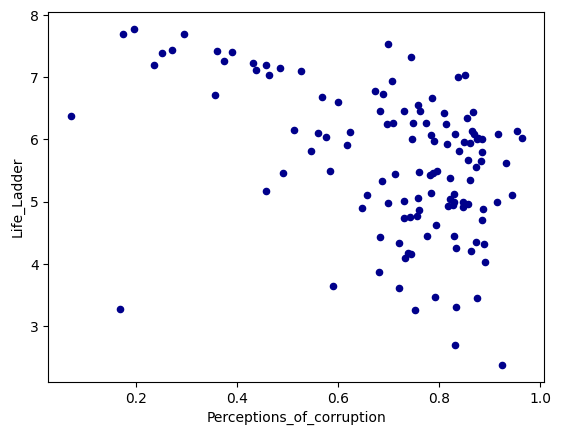

In [9]:
dados2019.plot.scatter(x='Perceptions_of_corruption',y='Life_Ladder',c='DarkBlue')

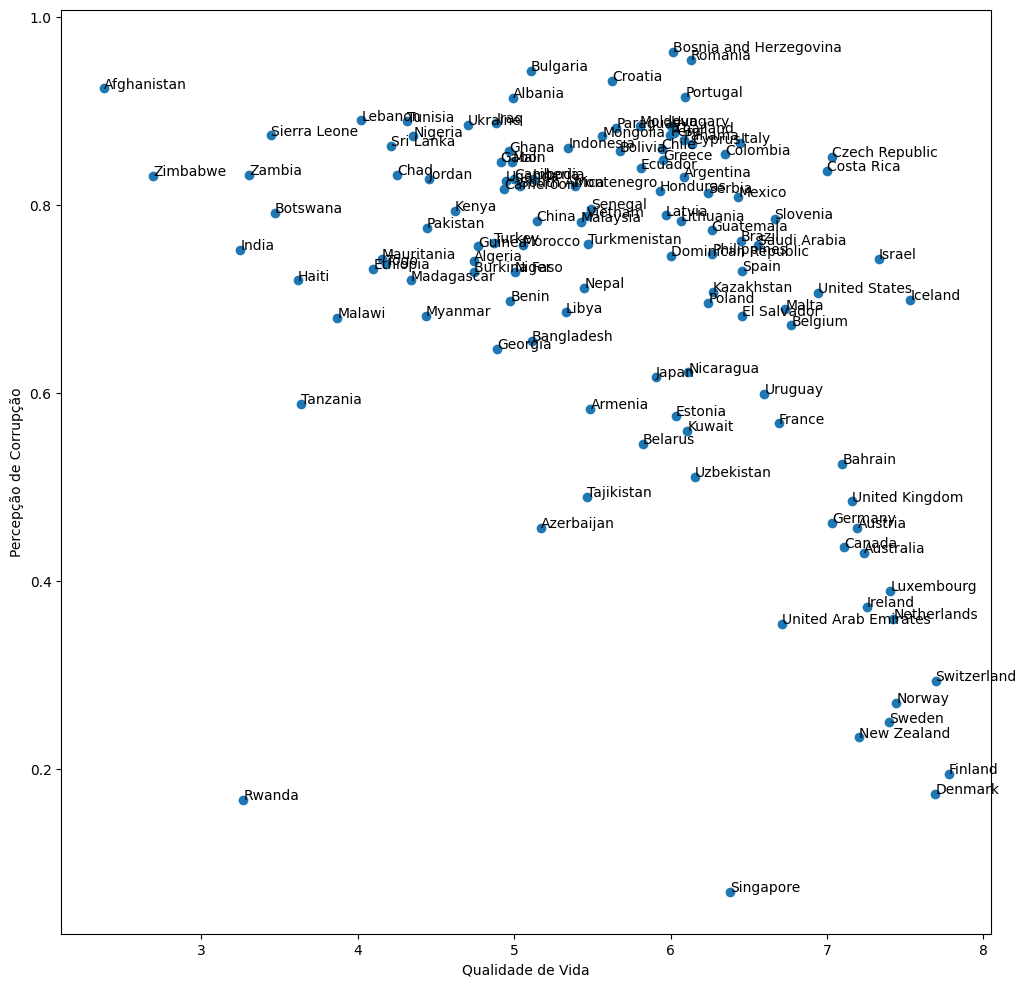

In [10]:
plt.figure(figsize=(12,12))
plt.scatter(dados2019.Life_Ladder, dados2019.Perceptions_of_corruption)
for _, row in dados2019.iterrows():
    plt.annotate(row.Name, (row.Life_Ladder, row.Perceptions_of_corruption))
plt.xlabel('Qualidade de Vida')
plt.ylabel('Percepção de Corrupção')
plt.show()

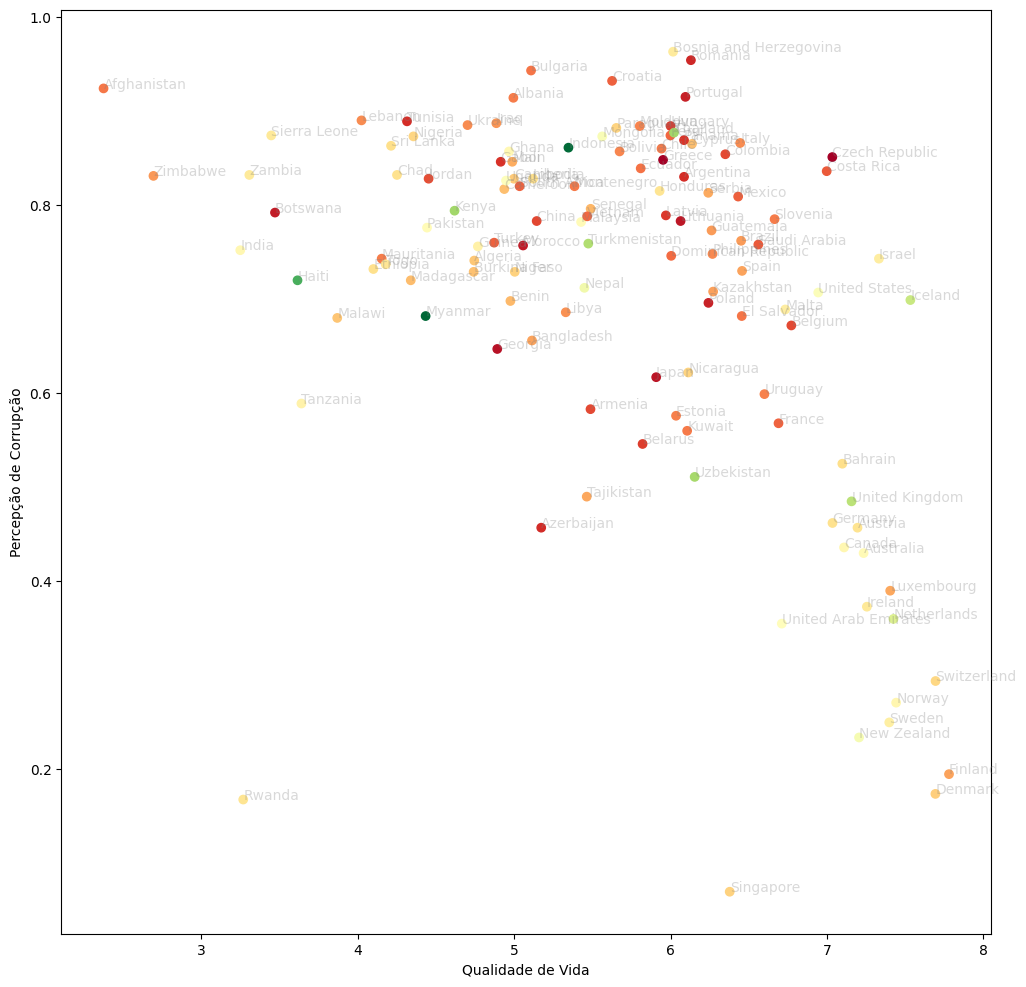

In [11]:
plt.figure(figsize=(12,12))
plt.scatter(dados2019.Life_Ladder, dados2019.Perceptions_of_corruption, c = dados2019.Generosity,cmap='RdYlGn')
for _, x in dados2019.iterrows():
    plt.annotate(x.Name, (x.Life_Ladder, x.Perceptions_of_corruption),c='grey',alpha=0.3)
plt.xlabel('Qualidade de Vida')
plt.ylabel('Percepção de Corrupção')
plt.show()

In [12]:
from sklearn.cluster import KMeans

In [13]:
dimensoes = [ 'Life_Ladder', 'Log_GDP_per_capita', 'Social_support',
             'Healthy_life_expectancy_at_birth', 'Freedom_to_make_life_choices',
             'Generosity', 'Perceptions_of_corruption', 'Positive_affect', 'Negative_affect']
Xs = dados2019[dimensoes]
Xs = (Xs - Xs.min())/(Xs.max()-Xs.min())
kmeans = KMeans(n_clusters=3)
kmeans.fit(Xs)
for i in range(3):
    MB = kmeans.labels_==i
    print('Cluster {}: {}'.format(i,dados2019[MB].Name.values))

Cluster 0: ['Australia' 'Austria' 'Bahrain' 'Canada' 'Denmark' 'Estonia' 'Finland'
 'France' 'Germany' 'Iceland' 'Ireland' 'Israel' 'Luxembourg' 'Malta'
 'Netherlands' 'New Zealand' 'Norway' 'Singapore' 'Sweden' 'Switzerland'
 'United Arab Emirates' 'United Kingdom' 'United States' 'Uruguay'
 'Uzbekistan']
Cluster 1: ['Albania' 'Algeria' 'Argentina' 'Armenia' 'Azerbaijan' 'Belarus'
 'Belgium' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus'
 'Czech Republic' 'Dominican Republic' 'Ecuador' 'El Salvador' 'Georgia'
 'Greece' 'Guatemala' 'Honduras' 'Hungary' 'Indonesia' 'Italy' 'Japan'
 'Jordan' 'Kazakhstan' 'Kuwait' 'Latvia' 'Libya' 'Lithuania' 'Malaysia'
 'Mexico' 'Moldova' 'Mongolia' 'Montenegro' 'Nicaragua' 'Panama'
 'Paraguay' 'Peru' 'Philippines' 'Poland' 'Portugal' 'Romania'
 'Saudi Arabia' 'Serbia' 'Slovenia' 'South Africa' 'Spain' 'Sri Lanka'
 'Tajikistan' 'Thailand' 'Turkey' 'Turkmenistan' 'Ukraine' 'Vie

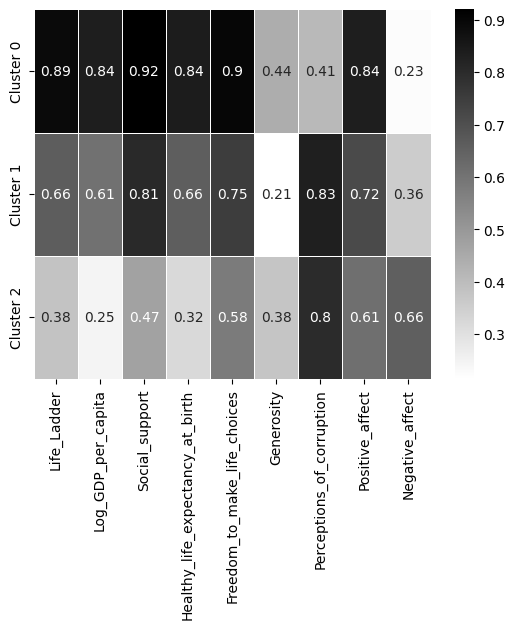

In [14]:
import seaborn as sns
clusters = ['Cluster {}'.format(i) for i in range(3)]
centroides = pd.DataFrame(0.0, index =  clusters, columns = Xs.columns)
for i,clst in enumerate(clusters):
    MB = kmeans.labels_==i
    centroides.loc[clst] = Xs[MB].median(axis=0)
sns.heatmap(centroides, linewidths=.5, annot=True, cmap='binary')
plt.show()